In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

## Load data

Load human-curated markers, LLM-generated markers, and DEG lists for all 7 datasets.

In [2]:
datasets = [
    "adipose_Emont2022",
    "adipose_Hildreth2021",
    "bone_He2021",
    "eye_Gautam2021",
    "lung_Adams2020",
    "ovary_Wagner2020",
    "testis_Shamis2020",
]

degs, humans, gens = [], [], []
for ds in datasets:
    d = pd.read_json(f"../data/{ds}/evidence_deg/extracted.json").assign(ds_name=ds)
    degs.append(d)
    
    h = pd.read_json(f"../data/{ds}/evidence_human/extracted.json").assign(ds_name=ds)
    h = h.dropna(subset=["group_name"])
    humans.append(h)
    
    g = pd.read_json(f"../data/{ds}/evidence_generated/extracted.json").assign(ds_name=ds)
    gens.append(g)

deg = pd.concat(degs).dropna(subset="feature_id")
human = pd.concat(humans).drop_duplicates(subset=["ds_name", "data_id", "source_type", "group_name", "feature_id"])
gen = pd.concat(gens).dropna(subset="feature_id")

print(f"DEG:       {len(deg):>7} records, {deg['feature_id'].nunique()} genes")
print(f"Human:     {len(human):>7} records, {human['feature_id'].dropna().nunique()} genes")
print(f"Generated: {len(gen):>7} records, {gen['feature_id'].nunique()} genes")

DEG:        224084 records, 15259 genes
Human:        1987 records, 629 genes
Generated:    1390 records, 633 genes


## Match generated markers to DEG ranks

Generated markers have no `data_id` (they are not tied to a specific supplementary table).
For each dataset, we match generated (group_name, feature_id) pairs against every DEG data_id
where that cell type appears. This gives us the rank of each generated marker in each DEG list.

For human markers, we do the same matching as in `lfc_comparison.ipynb` — joining on
the 4-part key (ds_name, data_id, group_name, feature_id).

In [3]:
# Match generated markers to DEGs.
# Since generated markers have no data_id, we match (group_name, feature_id)
# against ALL data_ids in the DEG for each dataset. This produces one row per
# (ds_name, data_id, group_name, feature_id) match.

gen_matched_parts = []
for ds in datasets:
    g_ds = gen.query(f"ds_name == '{ds}'")[["group_name", "feature_id", "feature_name", "ds_name"]].drop_duplicates()
    d_ds = deg.query(f"ds_name == '{ds}'")[["group_name", "feature_id", "data_id", "metrics_pcorr", "metrics_logfc", "metrics_rank"]]
    
    # Inner join on (group_name, feature_id) — picks up all data_ids
    merged = g_ds.merge(d_ds, on=["group_name", "feature_id"], how="inner")
    gen_matched_parts.append(merged)

gen_matched = pd.concat(gen_matched_parts)
print(f"Generated markers matched to DEG: {len(gen_matched)} records")
print(f"Unique (group_name, feature_id) pairs: {gen_matched.drop_duplicates(subset=['ds_name','group_name','feature_id']).shape[0]}")
print()
print("Per dataset:")
for ds in datasets:
    sub = gen_matched.query(f"ds_name == '{ds}'")
    n_gen = gen.query(f"ds_name == '{ds}'").drop_duplicates(subset=['group_name','feature_id']).shape[0]
    n_matched = sub.drop_duplicates(subset=['group_name','feature_id']).shape[0]
    print(f"  {ds}: {n_matched}/{n_gen} pairs matched ({n_matched/n_gen*100:.0f}%), {sub['data_id'].nunique()} data_ids")

Generated markers matched to DEG: 1421 records
Unique (group_name, feature_id) pairs: 845

Per dataset:
  adipose_Emont2022: 158/317 pairs matched (50%), 6 data_ids
  adipose_Hildreth2021: 188/249 pairs matched (76%), 4 data_ids
  bone_He2021: 96/203 pairs matched (47%), 5 data_ids
  eye_Gautam2021: 159/243 pairs matched (65%), 7 data_ids
  lung_Adams2020: 131/165 pairs matched (79%), 6 data_ids
  ovary_Wagner2020: 47/69 pairs matched (68%), 3 data_ids
  testis_Shamis2020: 66/144 pairs matched (46%), 6 data_ids


In [4]:
# Match human markers to DEGs (same approach as lfc_comparison)
human_matched_parts = []
for st in ["text", "image"]:
    h_st = human.query(f"source_type == '{st}'").set_index(["ds_name", "data_id", "group_name", "feature_id"])
    d_idx = deg.set_index(["ds_name", "data_id", "group_name", "feature_id"])
    comm = h_st.index.intersection(d_idx.index)
    matched = d_idx.loc[comm][["metrics_pcorr", "metrics_logfc", "metrics_rank"]].reset_index()
    matched["source_type"] = st
    human_matched_parts.append(matched)

human_matched = pd.concat(human_matched_parts)
print(f"Human text matched:  {len(human_matched.query('source_type == \"text\"'))}")
print(f"Human image matched: {len(human_matched.query('source_type == \"image\"'))}")

Human text matched:  303
Human image matched: 763


In [5]:
# LFC summary statistics for matched human markers
lfc_all = human_matched["metrics_logfc"].abs()
print("=== LFC summary (|log fold change|) ===")
print(f"All matched:  median={lfc_all.median():.2f}, IQR {lfc_all.quantile(0.25):.2f}--{lfc_all.quantile(0.75):.2f}")
for st in ["text", "image"]:
    lfc_st = human_matched.query(f'source_type == "{st}"')["metrics_logfc"].abs()
    print(f"  {st:>5}: median={lfc_st.median():.2f}, IQR {lfc_st.quantile(0.25):.2f}--{lfc_st.quantile(0.75):.2f}")

=== LFC summary (|log fold change|) ===
All matched:  median=1.19, IQR 0.66--2.00
   text: median=1.25, IQR 0.73--2.01
  image: median=1.17, IQR 0.65--1.98


## Rank distributions

In [6]:
print("=== Median rank ===")
print(f"Human text:  {human_matched.query('source_type == \"text\"')['metrics_rank'].median():.0f}")
print(f"Human image: {human_matched.query('source_type == \"image\"')['metrics_rank'].median():.0f}")
print(f"Generated:   {gen_matched['metrics_rank'].median():.0f}")
print()
print("=== Mean rank ===")
print(f"Human text:  {human_matched.query('source_type == \"text\"')['metrics_rank'].mean():.0f}")
print(f"Human image: {human_matched.query('source_type == \"image\"')['metrics_rank'].mean():.0f}")
print(f"Generated:   {gen_matched['metrics_rank'].mean():.0f}")
print()
for thresh in [10, 25, 50, 100]:
    ht = human_matched.query('source_type == "text"')
    hi = human_matched.query('source_type == "image"')
    print(f"Top {thresh:>3}: text {(ht['metrics_rank']<=thresh).mean():.0%}, "
          f"image {(hi['metrics_rank']<=thresh).mean():.0%}, "
          f"generated {(gen_matched['metrics_rank']<=thresh).mean():.0%}")

=== Median rank ===
Human text:  40
Human image: 50
Generated:   72

=== Mean rank ===
Human text:  155
Human image: 207
Generated:   248

Top  10: text 24%, image 26%, generated 18%
Top  25: text 40%, image 39%, generated 30%
Top  50: text 53%, image 50%, generated 43%
Top 100: text 66%, image 62%, generated 57%


## Precision / Recall / F-score curves

For each dataset and marker source (human-text, human-image, generated), sweep a threshold N from 1 to 20,000.
At each N, the top-N DEGs are "predicted markers" and the marker set is "truth".

Since generated markers match across multiple data_ids, we pool all unique ranks per dataset.

In [7]:
def compute_fractions(ranks, n):
    """Precision and recall at threshold N."""
    ranks = sorted(ranks)
    total = len(ranks)
    in_top_n = sum(1 for r in ranks if r <= n)
    recall = in_top_n / total if total > 0 else 0
    precision = in_top_n / n if n > 0 else 0
    return precision, recall

def compute_fraction_curve(ranks, max_n=20000, step=5):
    """Sweep threshold and compute P/R/F at each."""
    results = []
    for n in range(1, max_n + 1, step):
        p, r = compute_fractions(ranks, n)
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0
        results.append((n, p, r, f))
    return np.array(results)

In [8]:
# Build per-dataset rank lists for all three sources
rows = []
for ds in datasets:
    # Human text: unique ranks across all data_ids for this dataset
    ht = human_matched.query(f"ds_name == '{ds}' and source_type == 'text'")
    ht_ranks = sorted(set(ht["metrics_rank"].dropna().astype(int).tolist()))
    
    # Human image
    hi = human_matched.query(f"ds_name == '{ds}' and source_type == 'image'")
    hi_ranks = sorted(set(hi["metrics_rank"].dropna().astype(int).tolist()))
    
    # Generated
    gm = gen_matched.query(f"ds_name == '{ds}'")
    gm_ranks = sorted(set(gm["metrics_rank"].dropna().astype(int).tolist()))
    
    rows.append({
        "ds_name": ds,
        "text": ht_ranks,
        "image": hi_ranks,
        "generated": gm_ranks,
    })

agg = pd.DataFrame(rows)

# Print counts
for _, row in agg.iterrows():
    print(f"{row['ds_name']}: text={len(row['text'])}, image={len(row['image'])}, generated={len(row['generated'])}")

adipose_Emont2022: text=22, image=96, generated=129
adipose_Hildreth2021: text=46, image=91, generated=171
bone_He2021: text=36, image=25, generated=125
eye_Gautam2021: text=16, image=157, generated=185
lung_Adams2020: text=31, image=90, generated=226
ovary_Wagner2020: text=31, image=33, generated=65
testis_Shamis2020: text=76, image=46, generated=79


In [9]:
agg = agg.assign(
    curve_text=agg["text"].apply(lambda r: compute_fraction_curve(r, max_n=20000, step=5)),
    curve_image=agg["image"].apply(lambda r: compute_fraction_curve(r, max_n=20000, step=5)),
    curve_generated=agg["generated"].apply(lambda r: compute_fraction_curve(r, max_n=20000, step=5)),
)

## F-score vs top-N plots (per dataset, all three sources)

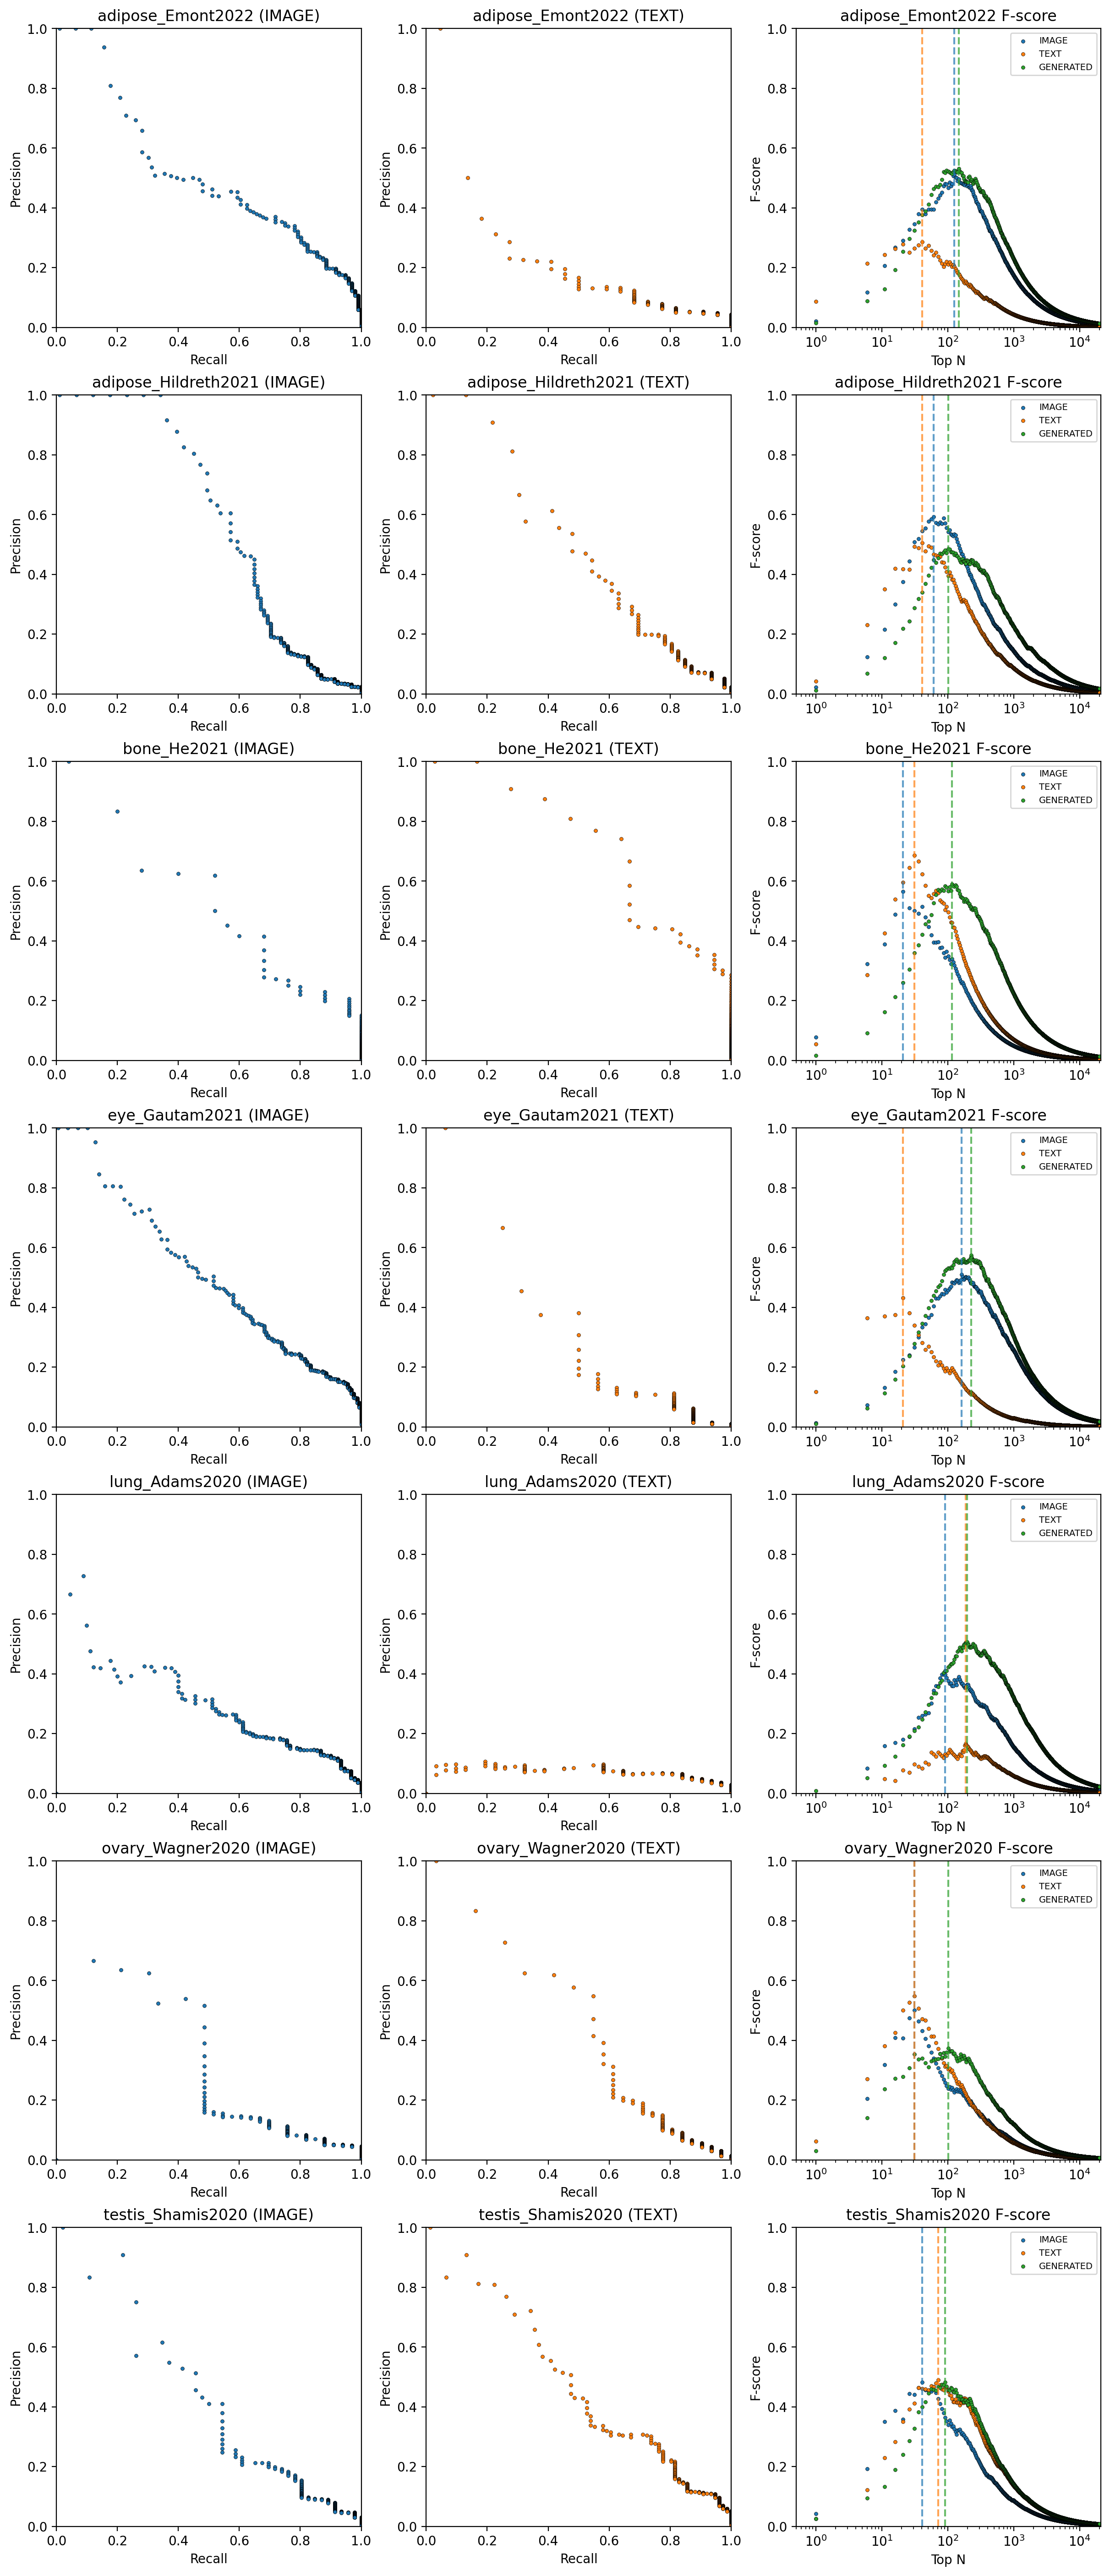

In [10]:
# Colors: image=#1f77b4, text=#ff7f0e, generated=#2ca02c (green)
fig, axs = plt.subplots(figsize=(12, 28), ncols=3, nrows=len(datasets), constrained_layout=True)

for i, ds in enumerate(datasets):
    # PR curve: image
    ax = axs[i, 0]
    curve = agg["curve_image"].iloc[i]
    ax.scatter(curve[:, 2], curve[:, 1], edgecolor="k", linewidth=0.25, color="#1f77b4", s=8)
    ax.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1), title=f"{ds} (IMAGE)")

    # PR curve: text
    ax = axs[i, 1]
    curve = agg["curve_text"].iloc[i]
    ax.scatter(curve[:, 2], curve[:, 1], edgecolor="k", linewidth=0.25, color="#ff7f0e", s=8)
    ax.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1), title=f"{ds} (TEXT)")

    # F-score vs top-N: all three
    ax = axs[i, 2]
    for src, color, label in [("curve_image", "#1f77b4", "IMAGE"),
                               ("curve_text", "#ff7f0e", "TEXT"),
                               ("curve_generated", "#2ca02c", "GENERATED")]:
        curve = agg[src].iloc[i]
        n_vals = curve[:, 0]
        f_vals = curve[:, 3]
        mask = f_vals > 0
        ax.scatter(n_vals[mask], f_vals[mask], label=label, edgecolor="k", linewidth=0.25, color=color, s=8)
        if mask.any():
            best_idx = np.argmax(f_vals[mask])
            ax.axvline(n_vals[mask][best_idx], linestyle="--", color=color, alpha=0.7)
    ax.set(xlabel="Top N", ylabel="F-score", xlim=0.5, ylim=(0, 1), xscale="log", title=f"{ds} F-score")
    ax.legend(fontsize=7)

import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/fig_gen_fscore_topn.pdf", bbox_inches="tight")
plt.show()

## Summary: optimal N and peak F-score

In [11]:
def summarize_curves(agg, src_col, rank_col):
    rows = []
    for _, row in agg.iterrows():
        curve = row[src_col]
        ranks = np.array(row[rank_col])
        argmax = curve[:, 3].argmax()
        rows.append({
            "dataset": row["ds_name"],
            "n_markers": len(ranks),
            "median_rank": int(np.median(ranks)) if len(ranks) > 0 else None,
            "opt_n": int(curve[argmax, 0]),
            "opt_p": curve[argmax, 1],
            "opt_r": curve[argmax, 2],
            "opt_f": curve[argmax, 3],
        })
    return pd.DataFrame(rows)

sum_txt = summarize_curves(agg, "curve_text", "text")
sum_img = summarize_curves(agg, "curve_image", "image")
sum_gen = summarize_curves(agg, "curve_generated", "generated")

print("=== Human TEXT ===")
print(sum_txt.to_string(index=False))
print(f"Mean opt_n: {sum_txt['opt_n'].mean():.0f}, Mean opt_f: {sum_txt['opt_f'].mean():.2f}")
print()
print("=== Human IMAGE ===")
print(sum_img.to_string(index=False))
print(f"Mean opt_n: {sum_img['opt_n'].mean():.0f}, Mean opt_f: {sum_img['opt_f'].mean():.2f}")
print()
print("=== GENERATED ===")
print(sum_gen.to_string(index=False))
print(f"Mean opt_n: {sum_gen['opt_n'].mean():.0f}, Mean opt_f: {sum_gen['opt_f'].mean():.2f}")

=== Human TEXT ===
             dataset  n_markers  median_rank  opt_n    opt_p    opt_r    opt_f
   adipose_Emont2022         22           78     41 0.219512 0.409091 0.285714
adipose_Hildreth2021         46           49     41 0.536585 0.478261 0.505747
         bone_He2021         36           22     31 0.741935 0.638889 0.686567
      eye_Gautam2021         16           34     21 0.380952 0.500000 0.432432
      lung_Adams2020         31          180    186 0.096774 0.580645 0.165899
    ovary_Wagner2020         31           28     31 0.548387 0.548387 0.548387
   testis_Shamis2020         76           90     71 0.507042 0.473684 0.489796
Mean opt_n: 60, Mean opt_f: 0.44

=== Human IMAGE ===
             dataset  n_markers  median_rank  opt_n    opt_p    opt_r    opt_f
   adipose_Emont2022         96          104    126 0.452381 0.593750 0.513514
adipose_Hildreth2021         91           69     61 0.737705 0.494505 0.592105
         bone_He2021         25           21     21 0.6190

## Optimal N boxplot: human-text vs human-image vs generated

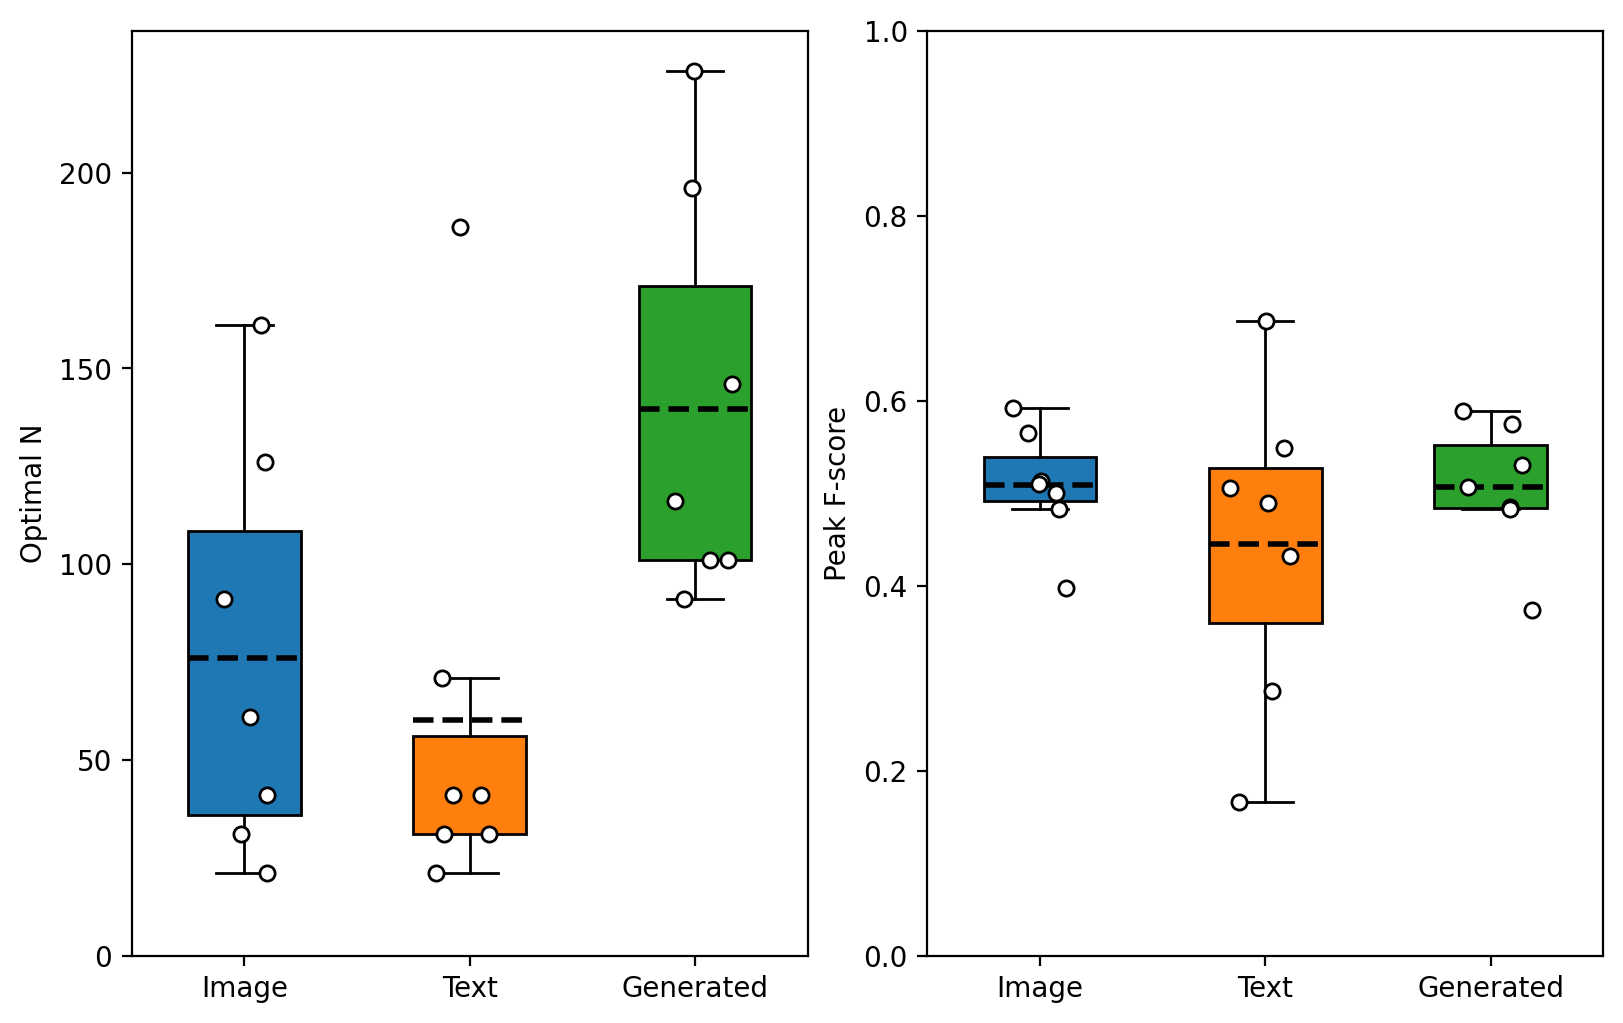

In [12]:
fig, axs = plt.subplots(figsize=(8, 5), ncols=2, constrained_layout=True)

# Optimal N
ax = axs[0]
data_box = [sum_img["opt_n"], sum_txt["opt_n"], sum_gen["opt_n"]]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
labels = ["Image", "Text", "Generated"]
bp = ax.boxplot(data_box, positions=[1, 2, 3], widths=0.5, patch_artist=True,
                medianprops={"visible": False}, showfliers=False,
                showmeans=True, meanline=True,
                meanprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
for j, vals in enumerate(data_box):
    xx = np.random.normal(j + 1, 0.08, size=len(vals))
    ax.scatter(xx, vals, edgecolor="k", facecolor="white", zorder=10, s=30)
ax.set(xticks=[1, 2, 3], xticklabels=labels, ylabel="Optimal N", ylim=0)

# Peak F-score
ax = axs[1]
data_box = [sum_img["opt_f"], sum_txt["opt_f"], sum_gen["opt_f"]]
bp = ax.boxplot(data_box, positions=[1, 2, 3], widths=0.5, patch_artist=True,
                medianprops={"visible": False}, showfliers=False,
                showmeans=True, meanline=True,
                meanprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
for j, vals in enumerate(data_box):
    xx = np.random.normal(j + 1, 0.08, size=len(vals))
    ax.scatter(xx, vals, edgecolor="k", facecolor="white", zorder=10, s=30)
ax.set(xticks=[1, 2, 3], xticklabels=labels, ylabel="Peak F-score", ylim=(0, 1))

fig.savefig("figures/fig_gen_optimal_n.pdf", bbox_inches="tight")
plt.show()

## CDF of DEG rank: human-text vs human-image vs generated

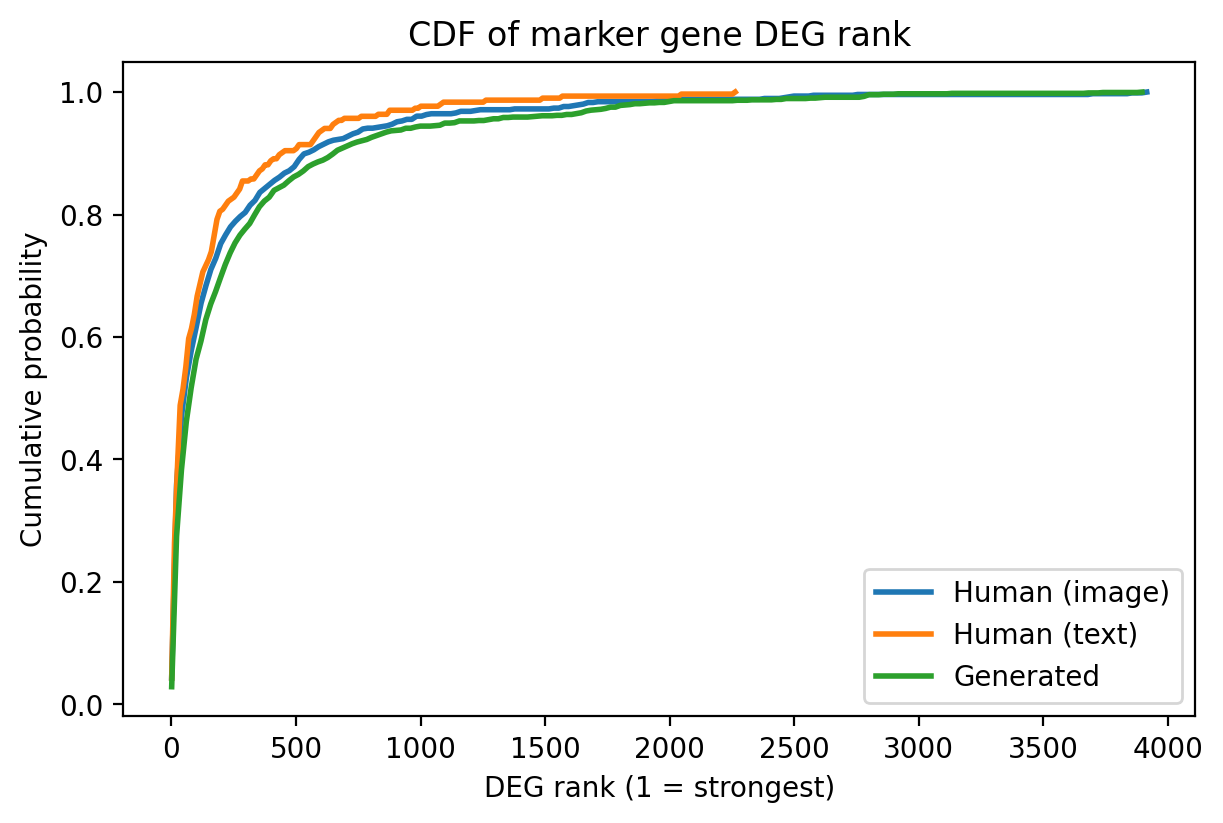

In [13]:
from statsmodels.distributions.empirical_distribution import ECDF

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

for src, color, label in [
    (human_matched.query('source_type == "image"')["metrics_rank"], "#1f77b4", "Human (image)"),
    (human_matched.query('source_type == "text"')["metrics_rank"], "#ff7f0e", "Human (text)"),
    (gen_matched["metrics_rank"], "#2ca02c", "Generated"),
]:
    ecdf = ECDF(src)
    x_vals = np.linspace(1, max(src.max(), 1000), 200)
    ax.plot(x_vals, ecdf(x_vals), label=label, color=color, linewidth=2)

ax.set(xlabel="DEG rank (1 = strongest)", ylabel="Cumulative probability",
       title="CDF of marker gene DEG rank")
ax.legend()
fig.savefig("figures/fig_gen_rank_cdf.pdf", bbox_inches="tight")
plt.show()

## Rank and LFC boxplots

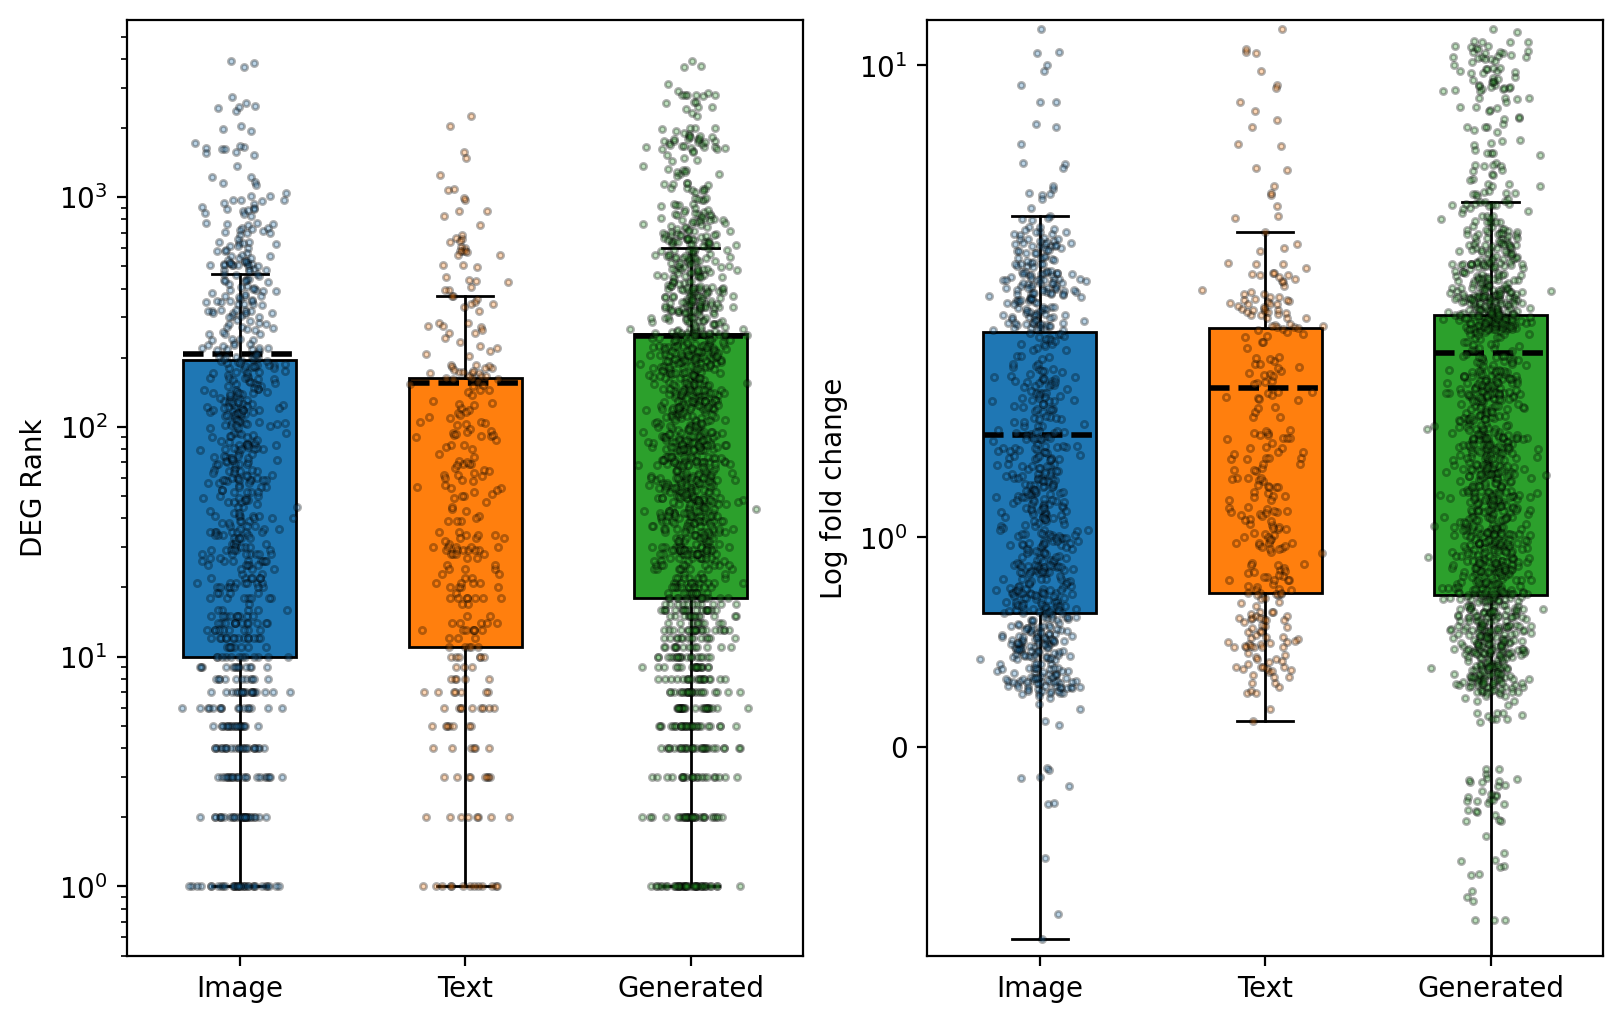

In [14]:
fig, axs = plt.subplots(figsize=(8, 5), ncols=2, constrained_layout=True)

# Rank boxplot
ax = axs[0]
data_box = [
    human_matched.query('source_type == "image"')["metrics_rank"].values,
    human_matched.query('source_type == "text"')["metrics_rank"].values,
    gen_matched["metrics_rank"].values,
]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
labels = ["Image", "Text", "Generated"]
bp = ax.boxplot(data_box, positions=[1, 2, 3], widths=0.5, patch_artist=True,
                medianprops={"visible": False}, showfliers=False,
                showmeans=True, meanline=True,
                meanprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
for j, vals in enumerate(data_box):
    xx = np.random.normal(j + 1, 0.08, size=len(vals))
    ax.scatter(xx, vals, edgecolor="k", facecolor=colors[j], zorder=10, s=5, alpha=0.3)
ax.set(xticks=[1, 2, 3], xticklabels=labels, ylabel="DEG Rank", yscale="log")
ax.set_ylim(0.5)

# LFC boxplot
ax = axs[1]
data_box = [
    human_matched.query('source_type == "image"')["metrics_logfc"].values,
    human_matched.query('source_type == "text"')["metrics_logfc"].values,
    gen_matched["metrics_logfc"].values,
]
bp = ax.boxplot(data_box, positions=[1, 2, 3], widths=0.5, patch_artist=True,
                medianprops={"visible": False}, showfliers=False,
                showmeans=True, meanline=True,
                meanprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
for j, vals in enumerate(data_box):
    xx = np.random.normal(j + 1, 0.08, size=len(vals))
    ax.scatter(xx, vals, edgecolor="k", facecolor=colors[j], zorder=10, s=5, alpha=0.3)
ax.set(xticks=[1, 2, 3], xticklabels=labels, ylabel="Log fold change", yscale="symlog")
ax.set_ylim(-1)

fig.savefig("figures/fig_gen_rank_lfc_boxplot.pdf", bbox_inches="tight")
plt.show()

## Per-dataset CDF comparison

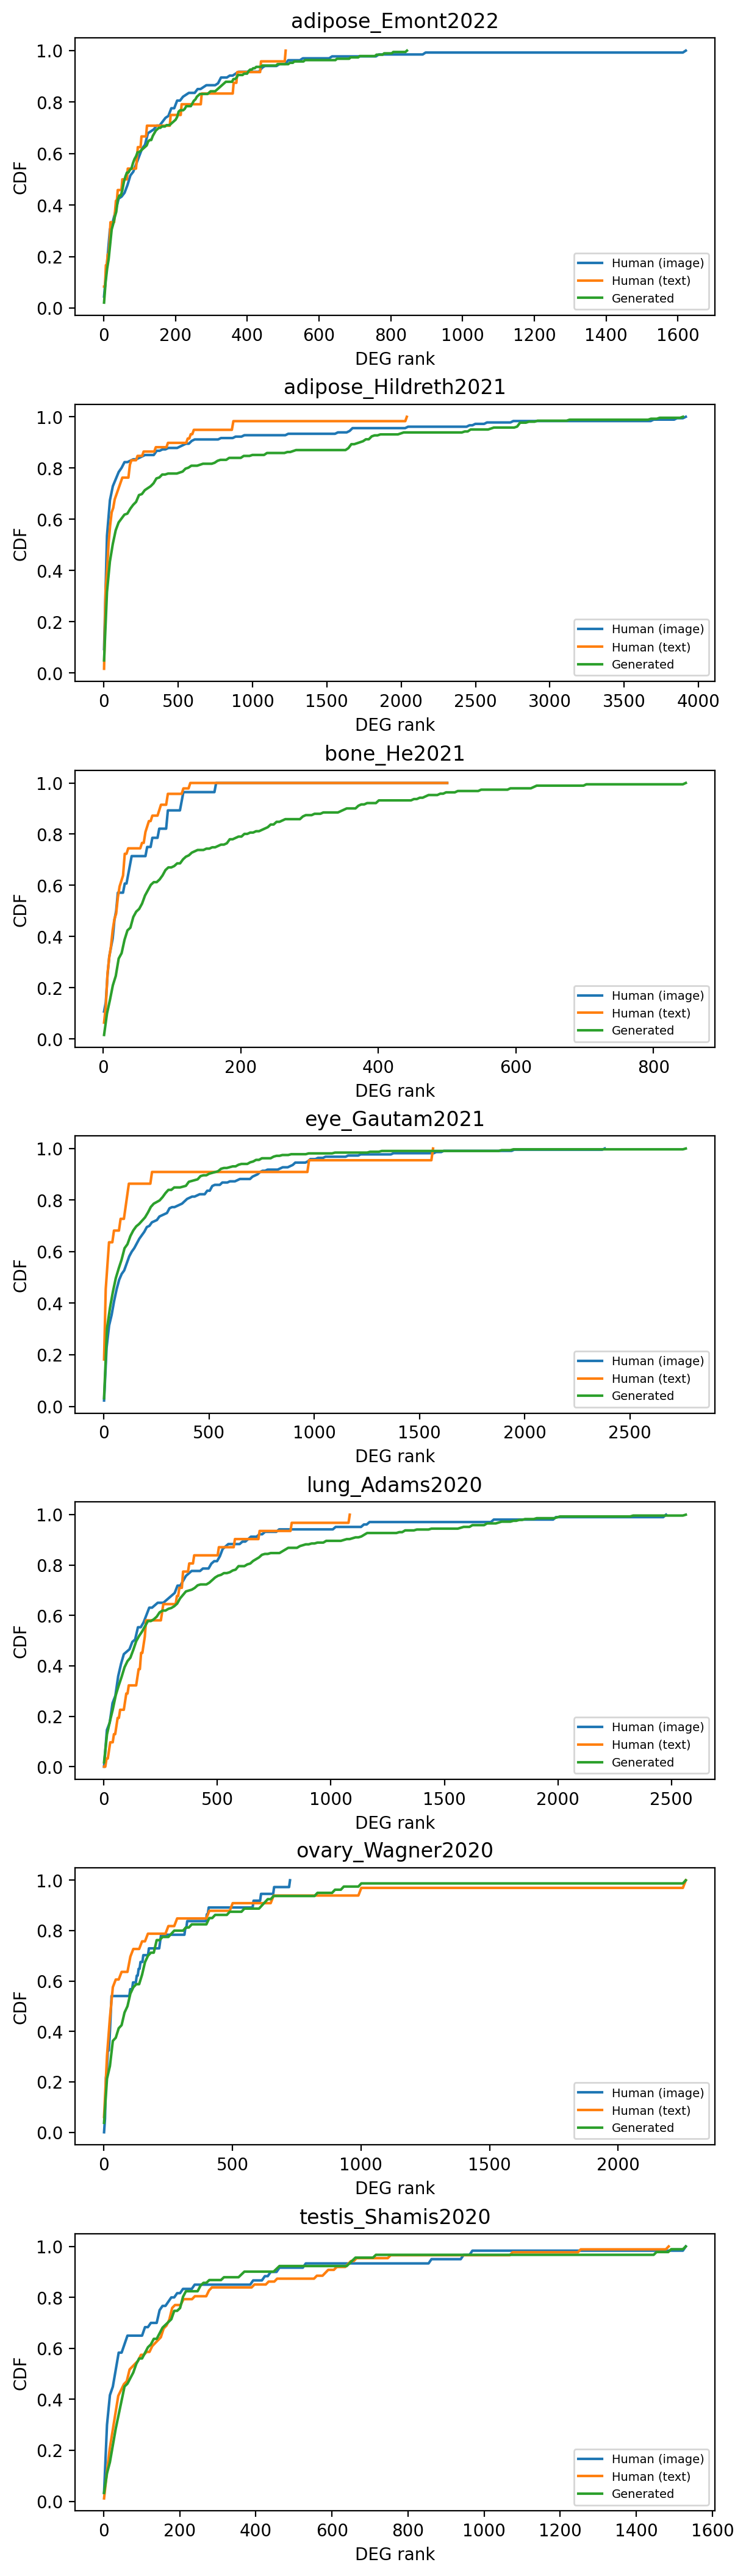

In [15]:
from statsmodels.distributions.empirical_distribution import ECDF

fig, axs = plt.subplots(nrows=len(datasets), ncols=1, figsize=(6, 3 * len(datasets)), constrained_layout=True)

for i, ds in enumerate(datasets):
    ax = axs[i]
    for src_df, query, color, label in [
        (human_matched, f"ds_name == '{ds}' and source_type == 'image'", "#1f77b4", "Human (image)"),
        (human_matched, f"ds_name == '{ds}' and source_type == 'text'", "#ff7f0e", "Human (text)"),
        (gen_matched, f"ds_name == '{ds}'", "#2ca02c", "Generated"),
    ]:
        vals = src_df.query(query)["metrics_rank"].dropna()
        if len(vals) > 0:
            ecdf = ECDF(vals)
            x_vals = np.linspace(1, max(vals.max(), 500), 200)
            ax.plot(x_vals, ecdf(x_vals), label=label, color=color, linewidth=1.5)
    ax.set(xlabel="DEG rank", ylabel="CDF", title=ds)
    ax.legend(fontsize=7)

fig.savefig("figures/fig_gen_rank_cdf_perdataset.pdf", bbox_inches="tight")
plt.show()

## Statistical tests

In [16]:
from scipy.stats import mannwhitneyu

gen_ranks = gen_matched["metrics_rank"].values
txt_ranks = human_matched.query('source_type == "text"')["metrics_rank"].values
img_ranks = human_matched.query('source_type == "image"')["metrics_rank"].values

print("Mann-Whitney U tests (rank):")
stat, p = mannwhitneyu(gen_ranks, txt_ranks)
print(f"  Generated vs Human text:  p = {p:.4f}")
stat, p = mannwhitneyu(gen_ranks, img_ranks)
print(f"  Generated vs Human image: p = {p:.4f}")

gen_lfc = gen_matched["metrics_logfc"].values
txt_lfc = human_matched.query('source_type == "text"')["metrics_logfc"].values
img_lfc = human_matched.query('source_type == "image"')["metrics_logfc"].values

print("\nMann-Whitney U tests (log fold change):")
stat, p = mannwhitneyu(gen_lfc, txt_lfc)
print(f"  Generated vs Human text:  p = {p:.4f}")
stat, p = mannwhitneyu(gen_lfc, img_lfc)
print(f"  Generated vs Human image: p = {p:.4f}")

Mann-Whitney U tests (rank):
  Generated vs Human text:  p = 0.0001
  Generated vs Human image: p = 0.0000

Mann-Whitney U tests (log fold change):
  Generated vs Human text:  p = 0.3709
  Generated vs Human image: p = 0.0009


In [17]:
print("=== Summary ===")
print(f"Generated markers total: {len(gen)} (across {gen['ds_name'].nunique()} datasets)")
print(f"Generated markers matched to DEG: {gen_matched.drop_duplicates(subset=['ds_name','group_name','feature_id']).shape[0]} unique pairs")
print(f"")
print(f"Optimal N (mean):  text={sum_txt['opt_n'].mean():.0f}, image={sum_img['opt_n'].mean():.0f}, generated={sum_gen['opt_n'].mean():.0f}")
print(f"Peak F (mean):     text={sum_txt['opt_f'].mean():.2f}, image={sum_img['opt_f'].mean():.2f}, generated={sum_gen['opt_f'].mean():.2f}")
print(f"Median rank:       text={human_matched.query('source_type==\"text\"')['metrics_rank'].median():.0f}, "
      f"image={human_matched.query('source_type==\"image\"')['metrics_rank'].median():.0f}, "
      f"generated={gen_matched['metrics_rank'].median():.0f}")

=== Summary ===
Generated markers total: 1390 (across 7 datasets)
Generated markers matched to DEG: 845 unique pairs

Optimal N (mean):  text=60, image=76, generated=140
Peak F (mean):     text=0.44, image=0.51, generated=0.51
Median rank:       text=40, image=50, generated=72


## Combined figure for "LLM extraction vs generation" section

2x3 layout: (a) CDF of DEG ranks, (b) rank boxplot, (c) LFC boxplot, (d) mean F-score vs top-N, (e) optimal N, (f) peak F-score.

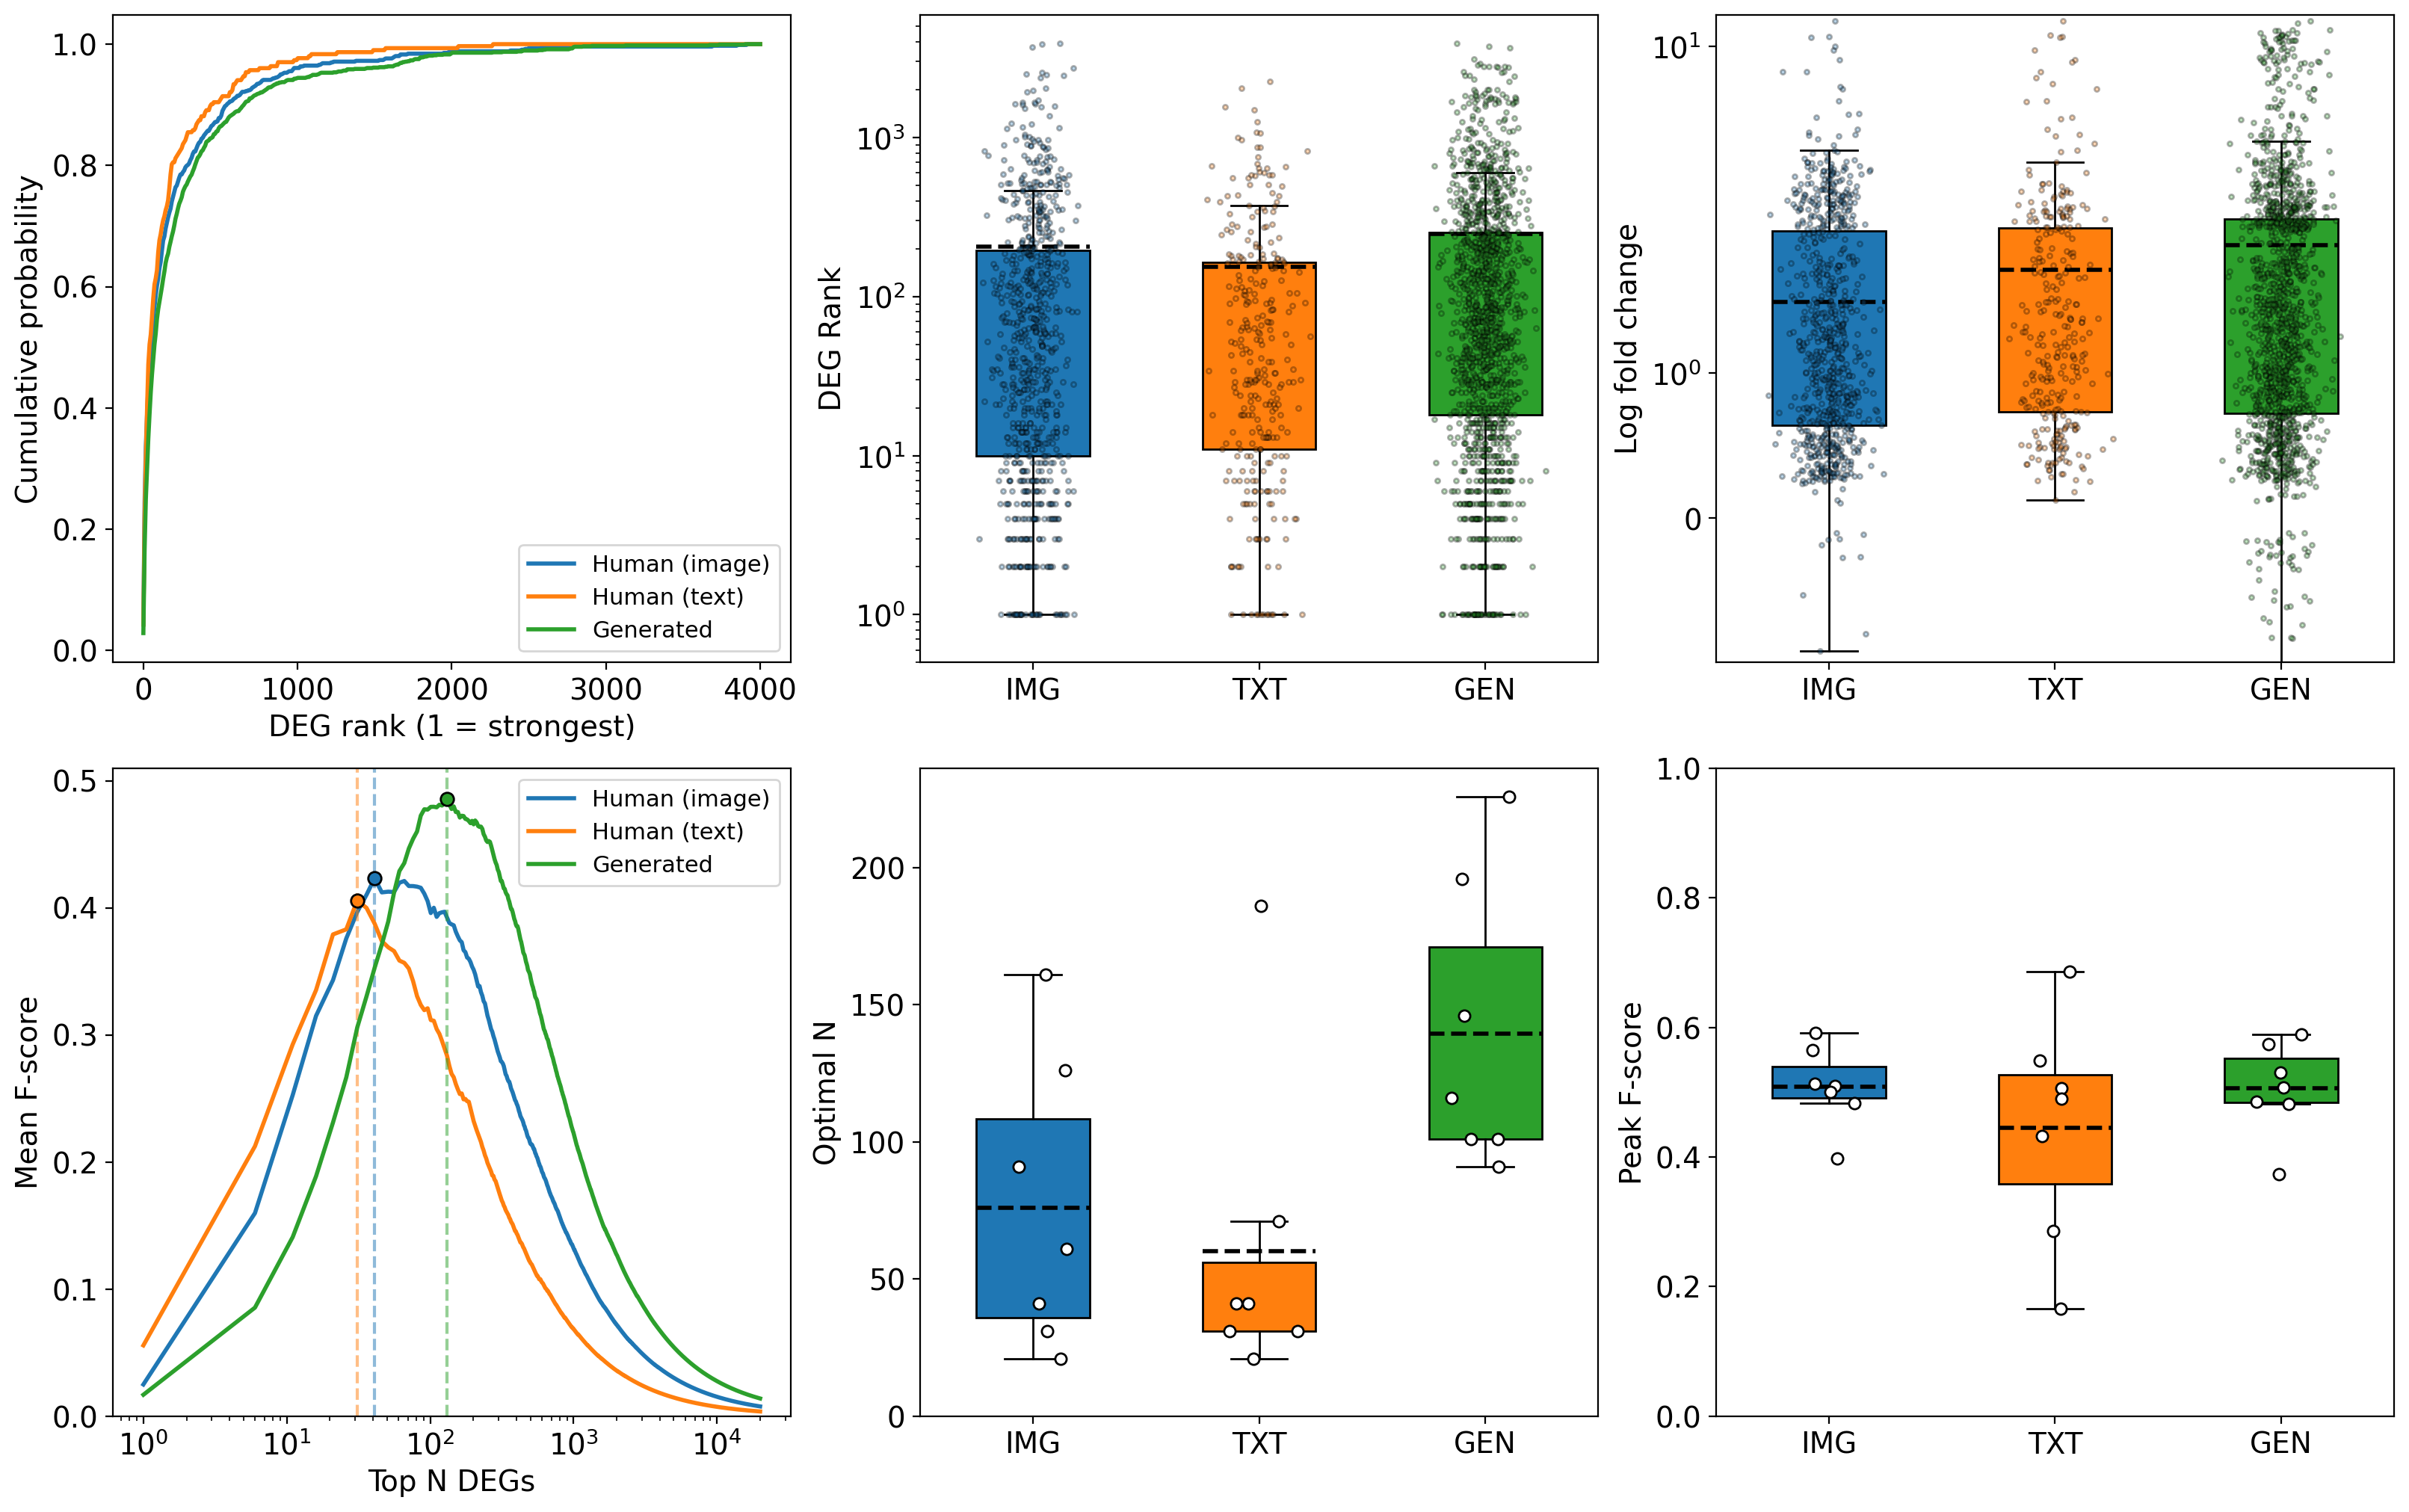

Saved: figures/fig_gen_comparison.pdf


In [18]:
from statsmodels.distributions.empirical_distribution import ECDF

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
labels_src = ["Human (image)", "Human (text)", "Generated"]
box_labels = ["IMG", "TXT", "GEN"]

with plt.rc_context({"font.size": 14}):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

    # --- (a) CDF of DEG ranks ---
    ax = axes[0, 0]
    for src, color, label in [
        (human_matched.query('source_type == "image"')["metrics_rank"], colors[0], labels_src[0]),
        (human_matched.query('source_type == "text"')["metrics_rank"], colors[1], labels_src[1]),
        (gen_matched["metrics_rank"], colors[2], labels_src[2]),
    ]:
        ecdf = ECDF(src)
        x_vals = np.linspace(1, max(src.max(), 4000), 500)
        ax.plot(x_vals, ecdf(x_vals), label=label, color=color, linewidth=2)
    ax.set(xlabel="DEG rank (1 = strongest)", ylabel="Cumulative probability")
    ax.legend(fontsize=11)

    # --- (b) Rank boxplot ---
    ax = axes[0, 1]
    data_rank = [
        human_matched.query('source_type == "image"')["metrics_rank"].values,
        human_matched.query('source_type == "text"')["metrics_rank"].values,
        gen_matched["metrics_rank"].values,
    ]
    bp = ax.boxplot(data_rank, positions=[1, 2, 3], widths=0.5, patch_artist=True,
                    medianprops={"visible": False}, showfliers=False,
                    showmeans=True, meanline=True,
                    meanprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    for j, vals in enumerate(data_rank):
        xx = np.random.normal(j + 1, 0.08, size=len(vals))
        ax.scatter(xx, vals, edgecolor="k", facecolor=colors[j], zorder=10, s=5, alpha=0.3)
    ax.set(xticks=[1, 2, 3], xticklabels=box_labels, ylabel="DEG Rank", yscale="log")
    ax.set_ylim(0.5)

    # --- (c) LFC boxplot ---
    ax = axes[0, 2]
    data_lfc = [
        human_matched.query('source_type == "image"')["metrics_logfc"].values,
        human_matched.query('source_type == "text"')["metrics_logfc"].values,
        gen_matched["metrics_logfc"].values,
    ]
    bp = ax.boxplot(data_lfc, positions=[1, 2, 3], widths=0.5, patch_artist=True,
                    medianprops={"visible": False}, showfliers=False,
                    showmeans=True, meanline=True,
                    meanprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    for j, vals in enumerate(data_lfc):
        xx = np.random.normal(j + 1, 0.08, size=len(vals))
        ax.scatter(xx, vals, edgecolor="k", facecolor=colors[j], zorder=10, s=5, alpha=0.3)
    ax.set(xticks=[1, 2, 3], xticklabels=box_labels, ylabel="Log fold change", yscale="symlog")
    ax.set_ylim(-1)

    # --- (d) Mean F-score vs top-N ---
    ax = axes[1, 0]
    for src_col, color, label in [
        ("curve_image", colors[0], labels_src[0]),
        ("curve_text", colors[1], labels_src[1]),
        ("curve_generated", colors[2], labels_src[2]),
    ]:
        curves = np.stack(agg[src_col].values)
        n_vals = curves[0, :, 0]
        mean_f = curves[:, :, 3].mean(axis=0)
        ax.plot(n_vals, mean_f, label=label, color=color, linewidth=2)
        best_idx = np.argmax(mean_f)
        ax.axvline(n_vals[best_idx], linestyle="--", color=color, alpha=0.5)
        ax.scatter([n_vals[best_idx]], [mean_f[best_idx]], color=color, edgecolor="k", zorder=10, s=40)
    ax.set(xlabel="Top N DEGs", ylabel="Mean F-score", xscale="log")
    ax.set_ylim(0)
    ax.legend(fontsize=11)

    # --- (e) Optimal N ---
    ax = axes[1, 1]
    data_optn = [sum_img["opt_n"], sum_txt["opt_n"], sum_gen["opt_n"]]
    bp = ax.boxplot(data_optn, positions=[1, 2, 3], widths=0.5, patch_artist=True,
                    medianprops={"visible": False}, showfliers=False,
                    showmeans=True, meanline=True,
                    meanprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    for j, vals in enumerate(data_optn):
        xx = np.random.normal(j + 1, 0.08, size=len(vals))
        ax.scatter(xx, vals, edgecolor="k", facecolor="white", zorder=10, s=30)
    ax.set(xticks=[1, 2, 3], xticklabels=box_labels, ylabel="Optimal N", ylim=0)

    # --- (f) Peak F-score ---
    ax = axes[1, 2]
    data_optf = [sum_img["opt_f"], sum_txt["opt_f"], sum_gen["opt_f"]]
    bp = ax.boxplot(data_optf, positions=[1, 2, 3], widths=0.5, patch_artist=True,
                    medianprops={"visible": False}, showfliers=False,
                    showmeans=True, meanline=True,
                    meanprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    for j, vals in enumerate(data_optf):
        xx = np.random.normal(j + 1, 0.08, size=len(vals))
        ax.scatter(xx, vals, edgecolor="k", facecolor="white", zorder=10, s=30)
    ax.set(xticks=[1, 2, 3], xticklabels=box_labels, ylabel="Peak F-score", ylim=(0, 1))

    import os
    os.makedirs("figures", exist_ok=True)
    fig.savefig("figures/fig_gen_comparison.pdf", bbox_inches="tight")
    plt.show()
    print("Saved: figures/fig_gen_comparison.pdf")